# Visualization of Local-Global Surprise

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import polars as pl
import seaborn as sns
from scipy.stats import mannwhitneyu, kruskal
from scikit_posthocs import posthoc_dunn

In [2]:
results_dir = Path('../../results/local_global_surprise')
dfs = []
for result in results_dir.iterdir():
    corpus_name = result.stem
    df = pl.read_ndjson(result).with_columns(pl.lit(corpus_name).alias('corpus'))
    dfs.append(df)

datasets_enum = pl.Enum(['humicroedit', 'puntuguese'])

# Dataframe has no 'label' column because they are all humorous texts
# They need to be humorous because we need pun and alternative words
# for the metric
df = (pl.concat(dfs, how='diagonal')
        .sort(pl.col('corpus').cast(datasets_enum)))
df

index,text,location,interpretation,local global surprise,corpus,funniness
str,str,str,str,f64,str,f64
"""humicroedit.14530.H""","""France is ‘ hunting down its c…","""twins""","""Isis""",-1.0,"""humicroedit""",0.2
"""humicroedit.13034.H""","""Pentagon claims 2,000 % increa…","""bowling""","""Syria""",-1.0,"""humicroedit""",1.6
"""humicroedit.8731.H""","""Iceland PM Calls Snap Vote as …","""party""","""Coalition""",1.778409,"""humicroedit""",1.0
"""humicroedit.76.H""","""In an apparent first , Iran an…","""slap""","""engage""",0.35875,"""humicroedit""",0.4
"""humicroedit.8832.H""","""All 22 sounds Trump made in hi…","""sounds""","""promises""",1.236339,"""humicroedit""",1.2
…,…,…,…,…,…,…
"""puntuguese.5.3487.H""","""Por que os editores da coquete…","""cruzadinhas""","""cruzadinhas""",-1.0,"""puntuguese""",null
"""puntuguese.5.2441.H""","""Qual é o pote que toca música?…","""spotefy""","""spotify""",0.657822,"""puntuguese""",null
"""puntuguese.5.988.H""","""Qual é o mosquito que pica pal…","""picadeiro""","""picadeiro""",-1.0,"""puntuguese""",null


## Check null values

In [3]:
(df.filter(pl.col('local global surprise') == -1)
   .group_by('corpus')
   .agg(pl.col('local global surprise').len()))

corpus,local global surprise
str,u64
"""puntuguese""",1332
"""humicroedit""",4214


In [4]:
df = df.filter(pl.col('local global surprise') != -1)
(df.group_by('corpus')
   .agg(pl.col('local global surprise').len()))

corpus,local global surprise
str,u64
"""puntuguese""",1510
"""humicroedit""",10082


## Plots

In [5]:
quantiles = (df.group_by('corpus')
               .agg(pl.col('local global surprise').quantile(0.25).alias('Q1'),
                    pl.col('local global surprise').quantile(0.5).alias('Q2'),
                    pl.col('local global surprise').quantile(0.75).alias('Q3'))
               .with_columns((pl.col('Q3') - pl.col('Q1')).alias('IQR'))
               .with_columns((pl.col('Q1') - 1.5 * pl.col('IQR')).alias('F1'),
                             (pl.col('Q3') + 1.5 * pl.col('IQR')).alias('F2')))
quantiles

corpus,Q1,Q2,Q3,IQR,F1,F2
str,f64,f64,f64,f64,f64,f64
"""humicroedit""",0.628802,0.822512,0.964966,0.336165,0.124555,1.469213
"""puntuguese""",0.757107,0.91264,1.036636,0.279529,0.337814,1.455929


In [6]:
df_with_quantiles = df.join(quantiles, on='corpus')
is_low_outlier = (pl.col('local global surprise') < pl.col('F1'))
is_high_outlier = (pl.col('local global surprise') > pl.col('F2'))
df_no_outliers = df_with_quantiles.filter(~(is_low_outlier | is_high_outlier)).select(df.columns)
df_no_outliers

index,text,location,interpretation,local global surprise,corpus,funniness
str,str,str,str,f64,str,f64
"""humicroedit.76.H""","""In an apparent first , Iran an…","""slap""","""engage""",0.35875,"""humicroedit""",0.4
"""humicroedit.8832.H""","""All 22 sounds Trump made in hi…","""sounds""","""promises""",1.236339,"""humicroedit""",1.2
"""humicroedit.12174.H""","""New DOJ alert system will flag…","""laughter""","""crimes""",0.709626,"""humicroedit""",1.2
"""humicroedit.3731.H""","""As Someone Who Grew Up Among F…","""morons""","""Christians""",0.876815,"""humicroedit""",1.0
"""humicroedit.6554.H""","""Canadians may pay more taxes t…","""loonies""","""money""",0.79512,"""humicroedit""",0.2
…,…,…,…,…,…,…
"""puntuguese.5.3439.H""","""O ganso chama sua esposa pra a…","""vem, gansa""","""vingança""",1.033562,"""puntuguese""",null
"""puntuguese.5.1849.H""","""Qual a parte do corpo mais atr…","""umbingo""","""umbigo""",0.808403,"""puntuguese""",null
"""puntuguese.5.57.H""","""Por que o quatro estava com um…","""cinco""","""circo""",1.23507,"""puntuguese""",null


### Surprise values without outliers

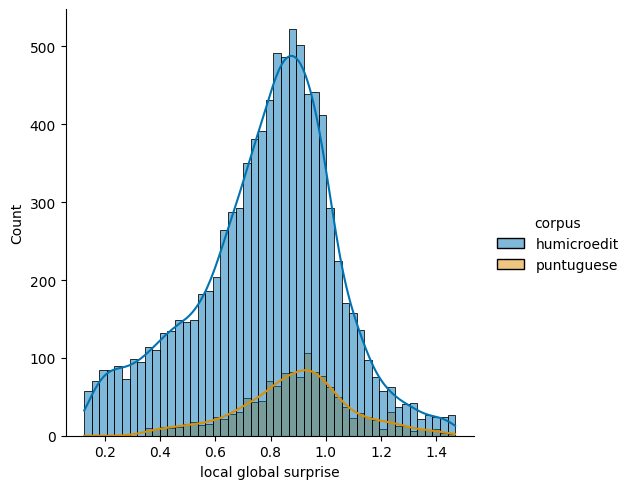

In [7]:
sns.displot(data=df_no_outliers, x='local global surprise',
            hue='corpus', palette='colorblind', kde=True)
plt.savefig('../../results/img/local_global_surprise.pdf')

### Humicroedit Surprise vs. Funniness

In [8]:
df_humicroedit = df_no_outliers.filter(pl.col('corpus') == 'humicroedit')

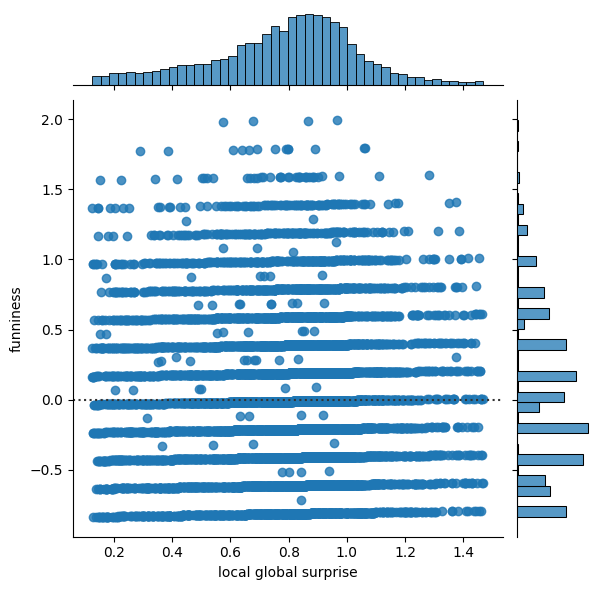

In [9]:
sns.jointplot(data=df_humicroedit, y='funniness', x='local global surprise',
              palette='colorblind', kind='resid')
plt.savefig('../../results/img/humicroedit_surprise_funniness.pdf')

### Visualize binned funniness

In [10]:
df_humicroedit = df_humicroedit.with_columns(pl.col('funniness')
                                             .qcut(3, labels=['low', 'mid', 'high'])
                                             .alias('funniness bin'))

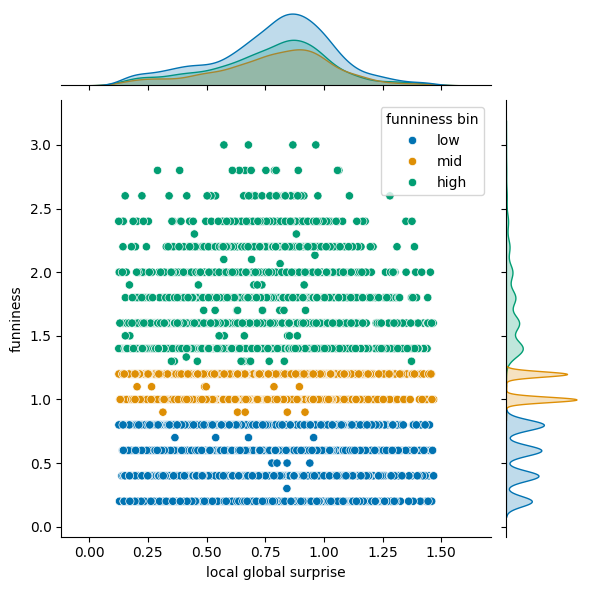

In [11]:
g = sns.jointplot(data=df_humicroedit, y='funniness', x='local global surprise',
                  palette='colorblind', hue='funniness bin')
plt.savefig('../../results/img/humicroedit_surprise_binned_funniness.pdf')

## Statistical tests (No outliers)

### Consistency accross corpora — Mann-Whitney U

In [12]:
data_humicroedit = df_humicroedit['local global surprise']
data_puntuguese = df_no_outliers.filter(pl.col('corpus') == 'puntuguese')['local global surprise']
statistic, pvalue = mannwhitneyu(data_humicroedit, data_puntuguese)
print(f'Statistic = {statistic}')
print(f'P-value = {pvalue:.4f}')
print(f'Different distributions: {pvalue < 0.5}')

Statistic = 4726130.0
P-value = 0.0000
Different distributions: True


### Humicroedit — Correlation Surprise vs. Funniness

In [13]:
(df_humicroedit.select(['funniness', 'local global surprise']).corr()['local global surprise'][0])

-0.01473917030139293

### Humicroedit — Binning analysis — Kruskal-Wallis H-test

In [14]:
binned_surprise = (df_humicroedit.select(['local global surprise', 'funniness bin'])
                                 .group_by('funniness bin')
                                 .all()['local global surprise']
                                 .to_numpy())
statistic, pvalue = kruskal(*binned_surprise)
print(f'Statistic = {statistic}')
print(f'P-value = {pvalue:.4f}')
print(f'Different distributions: {pvalue < 0.5}')

Statistic = 7.858783452327794
P-value = 0.0197
Different distributions: True


In [15]:
dunn_result = posthoc_dunn(binned_surprise, p_adjust='bonferroni')
dunn_result.columns = ['low', 'mid', 'high']
dunn_result.index = ['low', 'mid', 'high']
dunn_result

,low,mid,high
low,1.00000,1.000000,0.030120
mid,1.00000,1.000000,0.064643
high,0.03012,0.064643,1.000000
